In [ ]:
Assignment no : 05
name: Dipti Gosavi
Roll no : 13205
Problem Statement : Data Analytics II
1.Implement logistic regression using Python/R to perform classification on Social_Network_Ads.csv dataset.
2.Compute Confusion matrix to find TP, FP, TN, FN, Accuracy, Error rate, Precision, Recall on the given dataset.
Import Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
dataset = pd.read_csv("Social_Network_Ads.csv")
print(dataset.head())

   Age  EstimatedSalary  Purchased
0   19            19000          0
1   35            20000          0
2   26            43000          0
3   27            57000          0
4   19            76000          0


In [5]:
X = dataset.iloc[:, [0, 1]].values   # Age & EstimatedSalary
y = dataset.iloc[:, 2].values        # Purchased (0/1)

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0)

In [9]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [10]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [11]:
y_pred = model.predict(X_test)

In [12]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[65  3]
 [ 8 24]]


In [13]:
TN = cm[0][0]
FP = cm[0][1]
FN = cm[1][0]
TP = cm[1][1]

In [14]:
accuracy = (TP + TN) / (TP + TN + FP + FN)

In [15]:
error_rate = 1 - accuracy

In [16]:
precision = TP / (TP + FP)

In [17]:
recall = TP / (TP + FN)

In [18]:
print("TP:", TP)
print("TN:", TN)
print("FP:", FP)
print("FN:", FN)

print("Accuracy:", accuracy)
print("Error Rate:", error_rate)
print("Precision:", precision)
print("Recall:", recall)

TP: 24
TN: 65
FP: 3
FN: 8
Accuracy: 0.89
Error Rate: 0.10999999999999999
Precision: 0.8888888888888888
Recall: 0.75


In [19]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.96      0.92        68
           1       0.89      0.75      0.81        32

    accuracy                           0.89       100
   macro avg       0.89      0.85      0.87       100
weighted avg       0.89      0.89      0.89       100



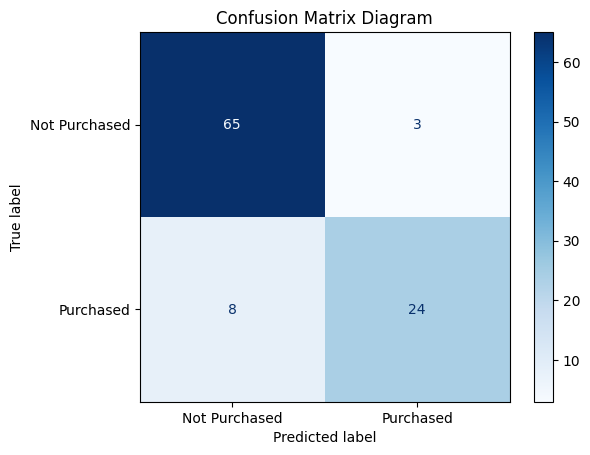

In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display diagram
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Purchased", "Purchased"])
disp.plot(cmap='Blues')

plt.title("Confusion Matrix Diagram")
plt.show()